RUNNING: PRACTICAL 1 ONLY PREDICTOR MODEL
Total Student Records: 1154
Failures (0): 267 | Passes (1): 887

Processing LOYOCV Fold: Test Year 2014

Processing LOYOCV Fold: Test Year 2015

Processing LOYOCV Fold: Test Year 2016

Processing LOYOCV Fold: Test Year 2017

Processing LOYOCV Fold: Test Year 2018

✓ COMPLETED. Results saved to Results\Notebook_Practical1_Only.xlsx

FINAL RESULTS SUMMARY: PRACTICAL 1 ONLY


,Model,Mean Recall (Fail),Mean AUC,Mean Bal. Acc
0,Logistic Regression,0.733,0.875,0.765
1,Random Forest,0.832,0.874,0.803
2,Gradient Boosting,0.773,0.874,0.808
3,SVM,0.446,0.661,0.664


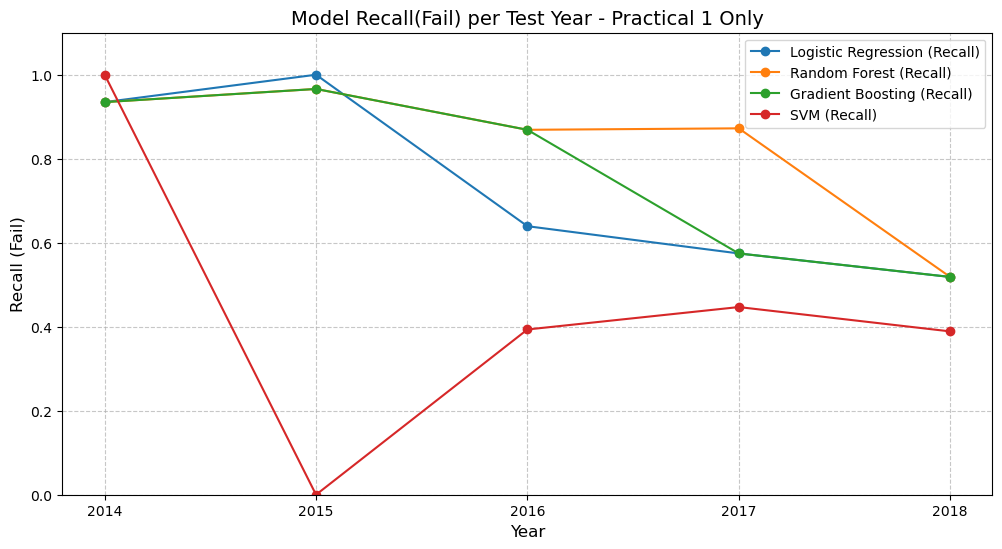

Point-Biserial Correlation between Practical 1 and Final Outcome: 0.495


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# NOTEBOOK: PRACTICAL 1 AS SOLE PREDICTOR
# Methodology: Practical 1 Normalised Score is the ONLY feature used.
# Logic: Excludes all Week 1-6 Mastery data/Behavioral features.
# ══════════════════════════════════════════════════════════════════════════════
import os, warnings
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)
from openpyxl import Workbook
from openpyxl.styles import Font
from openpyxl.utils import get_column_letter

warnings.filterwarnings('ignore')

# ── Configuration ──────────────────────────────────────────────────────────────
MASTERY_DATA_PATH = "mastery_data.xlsx"
RESULTS_DIR = "Results"
os.makedirs(RESULTS_DIR, exist_ok=True)
OUTPUT_FILE = os.path.join(RESULTS_DIR, "Notebook_Practical1_Only.xlsx")

print("=" * 80)
print("RUNNING: PRACTICAL 1 ONLY PREDICTOR MODEL")
print("=" * 80)

# ── Step 1: Load and Process Assessment Data ──────────────────────────────────
grade_frames = []

# Denominators for Normalisation
# 2014-2015: Practical 1 is /15
# 2016-2018: Practical 1 is /20
GRADE_CONFIGS = {
    2014: {"rename": {"new ID": "student_id", "practical 1 /15": "practical_1", "final grade": "final_grade"}, "denom": 15.0},
    2015: {"rename": {"new ID": "student_id", "practical 1 /15": "practical_1", "final grade": "final_grade"}, "denom": 15.0},
    2016: {"rename": {"new ID": "student_id", "practical 1 /20": "practical_1", "final grade": "final_grade"}, "denom": 20.0},
    2017: {"rename": {"new ID": "student_id", "practical 1 /20": "practical_1", "final grade": "final_grade"}, "denom": 20.0},
    2018: {"rename": {"new ID": "student_id", "practical 1 /20": "practical_1", "final grade": "final_grade"}, "denom": 20.0},
}

for yr, cfg in GRADE_CONFIGS.items():
    sheet_name = f"{yr} Assessment"
    try:
        df_yr = pd.read_excel(MASTERY_DATA_PATH, sheet_name=sheet_name)
        df_yr = df_yr.rename(columns=cfg["rename"])
        df_yr["year"] = yr
        # Only keep necessary columns and normalise
        df_yr = df_yr[["student_id", "year", "practical_1", "final_grade"]].copy()
        df_yr["practical_1_norm"] = df_yr["practical_1"] / cfg["denom"]
        grade_frames.append(df_yr)
    except Exception as e:
        print(f"  ⚠ Could not load {sheet_name}: {e}")

if not grade_frames:
    raise ValueError("No data loaded. Check if mastery_data.xlsx is in the current directory.")

full_df = pd.concat(grade_frames, ignore_index=True)

# ── Step 2: Binary Outcome Cleaning ──────────────────────────────────────────
PASS_GRADES = {"a", "b", "c", "a+", "a-", "b+", "b-", "c+", "c-"}
full_df["final_grade_clean"] = full_df["final_grade"].astype(str).str.strip().str.lower()
full_df["outcome"] = full_df["final_grade_clean"].apply(
    lambda g: 1 if g in PASS_GRADES else (0 if g in {"d","d+","d-","e","e+","e-","f"} else np.nan)
)

# Clean missing values for prediction
full_df = full_df.dropna(subset=["outcome", "practical_1_norm"])
full_df["outcome"] = full_df["outcome"].astype(int)

print(f"Total Student Records: {len(full_df)}")
print(f"Failures (0): {(full_df['outcome']==0).sum()} | Passes (1): {(full_df['outcome']==1).sum()}")

# ── Step 3: Feature Matrix Setup ──────────────────────────────────────────────
# SINGLE PREDICTOR ONLY
feature_cols = ["practical_1_norm"]
X_model = full_df[feature_cols].copy()
y = full_df["outcome"].copy()
year_col = full_df["year"].copy()

# ── Step 4: LOYOCV Evaluation ─────────────────────────────────────────────────
model_names = ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'SVM']
test_years = sorted(full_df["year"].unique())
all_results = {m: [] for m in model_names}
candidate_thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

def get_best_threshold(y_prob_val, y_val):
    best_thresh, best_ba = 0.50, 0.0
    for t in candidate_thresholds:
        y_hat = (y_prob_val >= t).astype(int)
        ba = balanced_accuracy_score(y_val, y_hat)
        if ba > best_ba:
            best_ba, best_thresh = ba, t
    return best_thresh

for test_year in test_years:
    print(f"\nProcessing LOYOCV Fold: Test Year {test_year}")
    
    train_mask = (year_col != test_year)
    test_mask = (year_col == test_year)
    
    X_train_f, y_train_f = X_model[train_mask], y[train_mask]
    X_test, y_test = X_model[test_mask], y[test_mask]
    
    # Validation split for thresholding
    X_tr, X_cal, y_tr, y_cal = train_test_split(
        X_train_f, y_train_f, test_size=0.20, stratify=y_train_f, random_state=42
    )
    
    clfs = {
        'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42),
        'Random Forest': RandomForestClassifier(class_weight='balanced', n_estimators=200, random_state=42),
        'Gradient Boosting': GradientBoostingClassifier(random_state=42),
        'SVM': SVC(class_weight='balanced', probability=True, random_state=42)
    }
    
    for name, model in clfs.items():
        # Calibrate Threshold
        model.fit(X_tr, y_tr)
        cal_probs = model.predict_proba(X_cal)[:, 1]
        best_t = get_best_threshold(cal_probs, y_cal)
        
        # Final Fit and Predict
        model.fit(X_train_f, y_train_f)
        test_probs = model.predict_proba(X_test)[:, 1]
        test_preds = (test_probs >= best_t).astype(int)
        
        all_results[name].append({
            'year': test_year,
            'threshold': best_t,
            'recall_fail': recall_score(y_test, test_preds, pos_label=0),
            'auc': roc_auc_score(y_test, test_probs),
            'bal_acc': balanced_accuracy_score(y_test, test_preds)
        })

# ── Step 5: Save to Excel ─────────────────────────────────────────────────────
wb = Workbook()
summary_ws = wb.active
summary_ws.title = "Mean Performance"
summary_ws.append(["Model", "Mean Recall(Fail)", "Mean AUC", "Mean Bal. Acc"])

for name in model_names:
    res_df = pd.DataFrame(all_results[name])
    summary_ws.append([
        name,
        res_df['recall_fail'].mean(),
        res_df['auc'].mean(),
        res_df['bal_acc'].mean()
    ])
    
    # Detailed sheet per model
    ws = wb.create_sheet(name[:30])
    ws.append(["Year", "Threshold", "Recall(Fail)", "AUC", "Bal. Acc"])
    for _, row in res_df.iterrows():
        ws.append(list(row))

wb.save(OUTPUT_FILE)
print(f"\n✓ COMPLETED. Results saved to {OUTPUT_FILE}")


# ══════════════════════════════════════════════════════════════════════════════
# NOTEBOOK OUTPUTS & VISUALIZATIONS
# ══════════════════════════════════════════════════════════════════════════════
from IPython.display import display, HTML
import matplotlib.pyplot as plt

print("\n" + "=" * 80)
print("FINAL RESULTS SUMMARY: PRACTICAL 1 ONLY")
print("=" * 80)

# 1. Generate and display Summary Table
summary_data = []
for name in model_names:
    res_df = pd.DataFrame(all_results[name])
    summary_data.append({
        "Model": name,
        "Mean Recall (Fail)": f"{res_df['recall_fail'].mean():.3f}",
        "Mean AUC": f"{res_df['auc'].mean():.3f}",
        "Mean Bal. Acc": f"{res_df['bal_acc'].mean():.3f}"
    })

summary_df = pd.DataFrame(summary_data)
display(HTML("<h3>Mean Performance Across All Years (2014-2018)</h3>"))
display(summary_df)

# 2. Plotting Performance Trends
plt.figure(figsize=(12, 6))
for name in model_names:
    res_df = pd.DataFrame(all_results[name])
    plt.plot(res_df['year'], res_df['recall_fail'], marker='o', label=f"{name} (Recall)")

plt.title("Model Recall(Fail) per Test Year - Practical 1 Only", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Recall (Fail)", fontsize=12)
plt.xticks(test_years)
plt.ylim(0, 1.1)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

# 3. Correlation Check
display(HTML("<h3>Predictor Insight</h3>"))
correlation = full_df['practical_1_norm'].corr(full_df['outcome'])
print(f"Point-Biserial Correlation between Practical 1 and Final Outcome: {correlation:.3f}")